In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [13]:
cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty']

df = pd.read_csv('data/KDDTrain+.txt', names=cols)
print(df.shape)


(125973, 43)


In [14]:
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [16]:
print(df['label'].value_counts())


label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


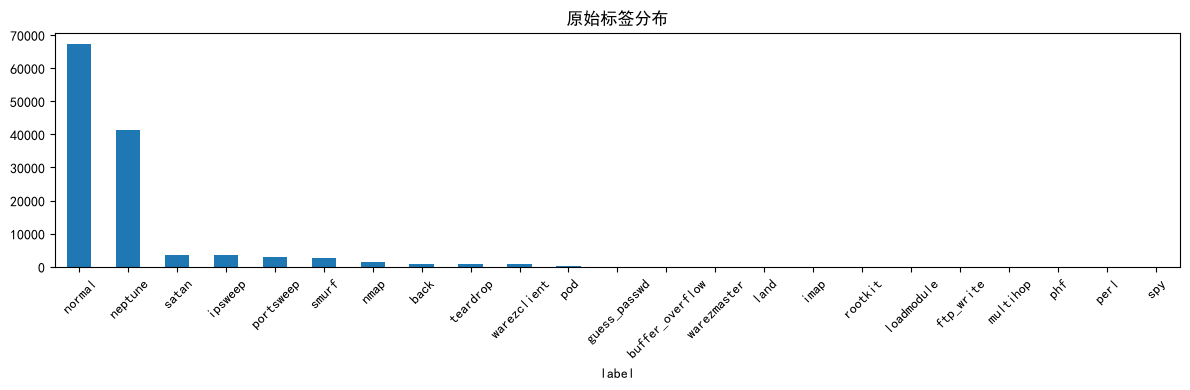

In [17]:
df['label'].value_counts().plot(kind='bar', figsize=(12,4))
plt.title('原始标签分布')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
def map_label(x):
    dos = ['neptune','smurf','back','teardrop','pod','land']
    probe = ['satan','ipsweep','nmap','portsweep']
    r2l = ['warezclient','warezmaster','ftp_write','imap','phf','multihop','guess_passwd','spy']
    u2r = ['buffer_overflow','loadmodule','rootkit','perl']
    if x == 'normal':
        return 0
    if x in dos:
        return 1
    if x in probe:
        return 2
    if x in r2l:
        return 3
    if x in u2r:
        return 4
    return -1

df['label5'] = df['label'].map(map_label)
print((df['label5'] == -1).sum())
print(df['label5'].value_counts())


0
label5
0    67343
1    45927
2    11656
3      995
4       52
Name: count, dtype: int64


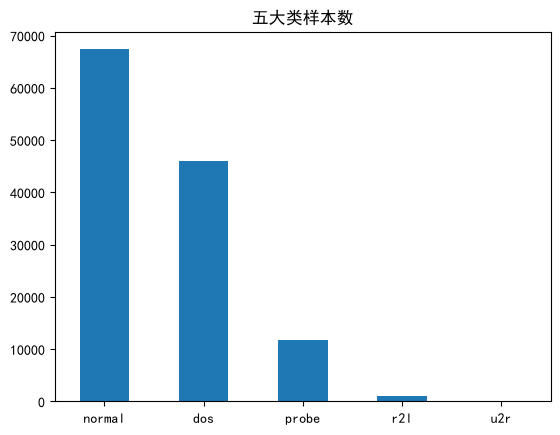

In [19]:
cnt = df['label5'].value_counts().sort_index()
cnt.index = ['normal','dos','probe','r2l','u2r']
cnt.plot(kind='bar')
plt.title('五大类样本数')
plt.xticks(rotation=0)
plt.show()


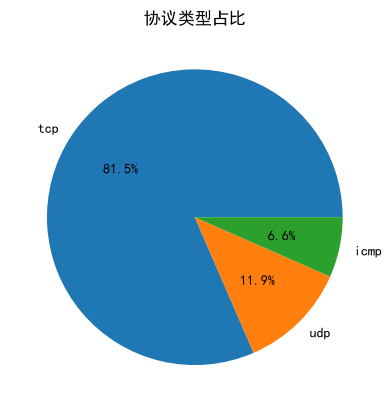

In [20]:
df['protocol_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('协议类型占比')
plt.ylabel('')
plt.show()


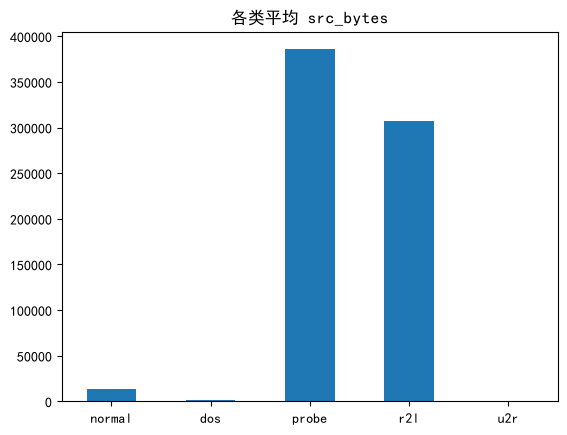

In [21]:
m = df.groupby('label5')['src_bytes'].mean()
m.index = ['normal','dos','probe','r2l','u2r']
m.plot(kind='bar')
plt.title('各类平均 src_bytes')
plt.xticks(rotation=0)
plt.show()


u2r 类样本极少，和 normal 差好几个数量级，后面建模必须处理类别不均衡，不能只看准确率。